**Salmon Fish Disease Classification**


This work uses the following public **dataset**:

Ahmed, Md Shoaib (2024), “SalmonScan: A Novel Image Dataset for Machine Learning and Deep Learning Analysis in Fish Disease Detection in Aquaculture”, Mendeley Data, V3.
DOI: 10.17632/x3fz2nfm4w.3
Dataset URL: https://data.mendeley.com/datasets/x3fz2nfm4w/3


The SalmonScan dataset contains salmon fish images categorized into two classes:

*   Fresh Salmon
*   Infected Salmon

The dataset is suitable for machine learning and deep learning-based fish disease detection in aquaculture systems.



Prepared by

Partha Pratim Ray, Sikkim University, India, May 24, 2026, parthapratimray1986@gmail.com, ppray@cus.ac.in

In [1]:
#Cell 1: Install libraries
!pip -q install timm ultralytics transformers accelerate torchmetrics scikit-learn seaborn opencv-python pillow pandas openpyxl statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 50.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 40.0 MB/s eta 0:00:00


In [2]:
# Cell 2: Imports and seed
import os, zipfile, shutil, time, random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import *
from statsmodels.stats.contingency_tables import mcnemar

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

import timm
from transformers import AutoModelForImageClassification

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cuda


In [9]:
# Cell 3: Download SalmonScan Version 3 and extract

DATA_DIR = Path("/content/salmonscan")
ZIP_PATH = Path("/content/salmonscan_v3.zip")

!rm -rf /content/salmonscan /content/salmonscan_v3.zip

!wget -O /content/salmonscan_v3.zip "https://data.mendeley.com/public-api/zip/x3fz2nfm4w/download/3"

print("Zip exists:", ZIP_PATH.exists())
print("Zip size MB:", ZIP_PATH.stat().st_size / (1024 * 1024))

DATA_DIR.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    print("First 50 zip entries:")
    for name in z.namelist()[:50]:
        print(name)
    z.extractall(DATA_DIR)

print("Extraction completed.")

--2026-05-24 14:22:58--  https://data.mendeley.com/public-api/zip/x3fz2nfm4w/download/3
Resolving data.mendeley.com (data.mendeley.com)... 162.159.130.86, 162.159.133.86
Connecting to data.mendeley.com (data.mendeley.com)|162.159.130.86|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://prod-dcd-datasets-cache-zipfiles.s3.eu-west-1.amazonaws.com/x3fz2nfm4w-3.zip?X-Amz-Security-Token=IQoJb3JpZ2luX2VjEIb%2F%2F%2F%2F%2F%2F%2F%2F%2F%2FwEaCWV1LXdlc3QtMSJHMEUCIQDH2LhfyjPr3VS2lPEm7tJM0nj46uBR9d0k5Hb5sFvYQwIgOKj2k0MeSKWmj3xRkSAxWUA1loexOiFBYo6VR0OXBT4qjAUITxAEGgwzNjcxNDczODM4MjUiDCPRcJhiaMza4LfKwyrpBDp4pPABsChA5T9mGawaznIZNGSRQDOe2hlI90LW%2F2jIAnOxvJsJ8d5du5AnoUEa6eg3gCGE9HricgDBwxg6aeUzlM%2Bg61HlM%2BOvuTyAdMwTC8NYz3HaIgM1EnNTbkQEpSHS2%2FKn9INvqaawVsxzx30quwFqlb2rD3%2B9h9f148TpdLnRBMq%2BgiDdS6s82Ok6I3GkusjSxbOUhQk7UmLSPSnfKVS%2BbYZH1wmksB8V%2BBm93XglJf2u8JUxFVGrn2YzhHz4ujfWwvu6CuKdvHoSwBgVUE1bVkvf3SPgPdKJsJq37HVVKYbTVI32wrRdu%2BXA%2BNKVlve5VQryRlAySdp4Cnn4UJ

In [11]:
# Cell 4: Extract nested SalmonScan.zip and discover images

INNER_ZIP = list(DATA_DIR.rglob("SalmonScan.zip"))

print("Nested zip files found:", INNER_ZIP)

if len(INNER_ZIP) == 0:
    raise ValueError("No nested SalmonScan.zip found.")

INNER_EXTRACT_DIR = DATA_DIR / "SalmonScan_extracted"
INNER_EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(INNER_ZIP[0], "r") as z:
    print("First 50 entries inside nested zip:")
    for name in z.namelist()[:50]:
        print(name)
    z.extractall(INNER_EXTRACT_DIR)

image_exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}

image_paths = [
    p for p in INNER_EXTRACT_DIR.rglob("*")
    if p.is_file() and p.suffix.lower() in image_exts
]

print("Total image files found:", len(image_paths))

if len(image_paths) == 0:
    print("Folder tree sample:")
    for p in list(INNER_EXTRACT_DIR.rglob("*"))[:150]:
        print(p)
    raise ValueError("No images found inside nested zip.")

df = pd.DataFrame({"path": [str(p) for p in image_paths]})

def infer_label(path):
    s = str(path).lower()

    if "infected" in s or "infect" in s or "disease" in s:
        return "InfectedFish"
    elif "fresh" in s or "healthy" in s:
        return "FreshFish"
    else:
        return "Unknown"

df["label"] = df["path"].apply(infer_label)

print("\nDetected labels:")
print(df["label"].value_counts())

print("\nSample rows:")
print(df.head(10).to_string(index=False))

Nested zip files found: [PosixPath('/content/salmonscan/SalmonScan A Novel Image Dataset for Machine Learning and Deep Learning Analysis in Fish Disease Detection in Aquaculture/SalmonScan.zip')]
First 50 entries inside nested zip:
SalmonScan/Augmented/
SalmonScan/Augmented/FreshFish/
SalmonScan/Augmented/FreshFish/fresh_0.png
SalmonScan/Augmented/FreshFish/fresh_1.png
SalmonScan/Augmented/FreshFish/fresh_10.png
SalmonScan/Augmented/FreshFish/fresh_100.png
SalmonScan/Augmented/FreshFish/fresh_101.png
SalmonScan/Augmented/FreshFish/fresh_102.png
SalmonScan/Augmented/FreshFish/fresh_103.png
SalmonScan/Augmented/FreshFish/fresh_104.png
SalmonScan/Augmented/FreshFish/fresh_105.png
SalmonScan/Augmented/FreshFish/fresh_106.png
SalmonScan/Augmented/FreshFish/fresh_107.png
SalmonScan/Augmented/FreshFish/fresh_108.png
SalmonScan/Augmented/FreshFish/fresh_109.png
SalmonScan/Augmented/FreshFish/fresh_11.png
SalmonScan/Augmented/FreshFish/fresh_110.png
SalmonScan/Augmented/FreshFish/fresh_111.png


In [12]:
# Cell 5: Train/validation/test split

WORK_DIR = Path("/content/salmon_ready")

if WORK_DIR.exists():
    shutil.rmtree(WORK_DIR)

for split in ["train", "val", "test"]:
    for cls in ["FreshFish", "InfectedFish"]:
        (WORK_DIR / split / cls).mkdir(parents=True, exist_ok=True)

train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df["label"], random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["label"], random_state=SEED
)

for split_name, split_df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    for _, row in split_df.iterrows():
        src = Path(row["path"])
        dst = WORK_DIR / split_name / row["label"] / src.name
        shutil.copy2(src, dst)

dist = []
for split in ["train", "val", "test"]:
    for cls in ["FreshFish", "InfectedFish"]:
        dist.append({
            "Split": split,
            "Class": cls,
            "Count": len(list((WORK_DIR / split / cls).glob("*")))
        })

dist_df = pd.DataFrame(dist)
print(dist_df.to_string(index=False))

Split        Class  Count
train    FreshFish    335
train InfectedFish    590
  val    FreshFish     72
  val InfectedFish    126
 test    FreshFish     72
 test InfectedFish    127


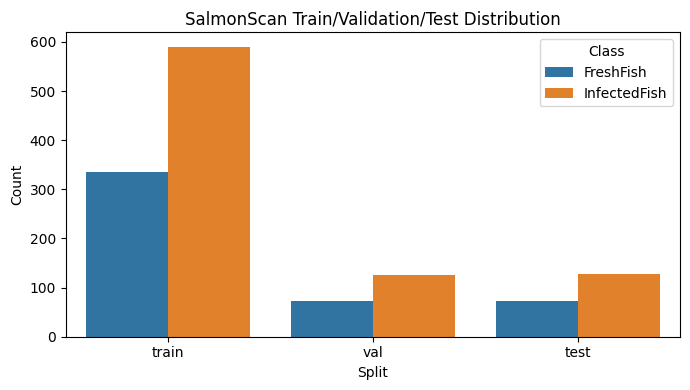

In [13]:
# Cell 6: Plot class distribution

plt.figure(figsize=(7,4))
sns.barplot(data=dist_df, x="Split", y="Count", hue="Class")
plt.title("SalmonScan Train/Validation/Test Distribution")
plt.tight_layout()
plt.show()

In [14]:
# Cell 7: Data loaders

IMG_SIZE = 224
BATCH_SIZE = 32

train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
])

eval_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
])

train_ds = datasets.ImageFolder(WORK_DIR / "train", transform=train_tfms)
val_ds   = datasets.ImageFolder(WORK_DIR / "val", transform=eval_tfms)
test_ds  = datasets.ImageFolder(WORK_DIR / "test", transform=eval_tfms)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

class_names = train_ds.classes
num_classes = len(class_names)

print(class_names)

['FreshFish', 'InfectedFish']


In [15]:
# Cell 8: Model factory with basic CNN + recent models

def build_model(model_name, num_classes=2):

    # Basic CNN / classical transfer-learning baselines
    if model_name == "alexnet":
        model = models.alexnet(weights=models.AlexNet_Weights.IMAGENET1K_V1)
        model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, num_classes)

    elif model_name == "vgg16":
        model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
        model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, num_classes)

    elif model_name == "vgg19":
        model = models.vgg19(weights=models.VGG19_Weights.IMAGENET1K_V1)
        model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, num_classes)

    elif model_name == "resnet18":
        model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        model.fc = nn.Linear(model.fc.in_features, num_classes)

    elif model_name == "resnet50":
        model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        model.fc = nn.Linear(model.fc.in_features, num_classes)

    elif model_name == "densenet121":
        model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)

    elif model_name == "inception_v3":
        model = models.inception_v3(weights=models.Inception_V3_Weights.IMAGENET1K_V1, aux_logits=True)
        model.fc = nn.Linear(model.fc.in_features, num_classes)

    elif model_name == "efficientnet_b0":
        model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, num_classes)

    # Recent lightweight timm model from Hugging Face
    elif model_name == "hf_mobilenetv3_small_lamb":
        model = timm.create_model(
            "hf_hub:timm/mobilenetv3_small_100.lamb_in1k",
            pretrained=True,
            num_classes=num_classes
        )

    # Vision transformer baselines
    elif model_name == "vit_base":
        model = timm.create_model(
            "vit_base_patch16_224",
            pretrained=True,
            num_classes=num_classes
        )

    elif model_name == "swinv2_tiny":
        model = timm.create_model(
            "swinv2_tiny_window8_256",
            pretrained=True,
            num_classes=num_classes
        )

    # Domain-unrelated but requested HF ViT model; useful only as transfer baseline
    elif model_name == "falconsai_nsfw_vit":
        model = AutoModelForImageClassification.from_pretrained(
            "Falconsai/nsfw_image_detection",
            num_labels=num_classes,
            ignore_mismatched_sizes=True
        )

    else:
        raise ValueError(f"Unknown model: {model_name}")

    return model.to(DEVICE)

In [16]:
# Cell 9: Training loop

def forward_logits(model, x):
    out = model(x)
    if hasattr(out, "logits"):
        return out.logits
    if isinstance(out, tuple):
        return out[0]
    return out


def run_one_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    criterion = nn.CrossEntropyLoss()
    total_loss = 0
    all_y, all_pred, all_prob = [], [], []

    with torch.set_grad_enabled(is_train):
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)

            logits = forward_logits(model, x)
            loss = criterion(logits, y)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            probs = torch.softmax(logits, dim=1)[:, 1]
            preds = torch.argmax(logits, dim=1)

            total_loss += loss.item() * x.size(0)
            all_y.extend(y.cpu().numpy())
            all_pred.extend(preds.cpu().numpy())
            all_prob.extend(probs.detach().cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_y, all_pred)
    f1 = f1_score(all_y, all_pred)

    return avg_loss, acc, f1, np.array(all_y), np.array(all_pred), np.array(all_prob)


def train_model(model_name, epochs=10, lr=1e-4):
    model = build_model(model_name, num_classes)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=1e-4
    )

    history = []
    best_f1 = -1
    best_path = f"/content/best_{model_name}.pt"

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc, tr_f1, *_ = run_one_epoch(model, train_loader, optimizer)
        va_loss, va_acc, va_f1, *_ = run_one_epoch(model, val_loader)

        row = {
            "epoch": epoch,
            "train_loss": tr_loss,
            "val_loss": va_loss,
            "train_acc": tr_acc,
            "val_acc": va_acc,
            "train_f1": tr_f1,
            "val_f1": va_f1
        }

        history.append(row)
        print(row)

        if va_f1 > best_f1:
            best_f1 = va_f1
            torch.save(model.state_dict(), best_path)

    model.load_state_dict(torch.load(best_path, map_location=DEVICE))
    return model, pd.DataFrame(history), best_path

In [17]:
# Cell 10: Select models to run

MODELS_TO_RUN = [
    # Basic CNN baselines
    "alexnet",
    "vgg16",
    "vgg19",
    "resnet18",
    "resnet50",
    "densenet121",
    "efficientnet_b0",

    # Recent/lightweight/requested models
    "hf_mobilenetv3_small_lamb",

    # Transformer models
    "vit_base",

    # Requested HF transfer baseline
    "falconsai_nsfw_vit"
]

all_histories = {}
trained_models = {}

for m in MODELS_TO_RUN:
    print("\n" + "="*80)
    print("Training:", m)
    print("="*80)

    try:
        model, hist, path = train_model(m, epochs=10, lr=1e-4)
        all_histories[m] = hist
        trained_models[m] = model
    except Exception as e:
        print(f"Skipped {m} due to error: {e}")


Training: alexnet
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:02<00:00, 106MB/s]


{'epoch': 1, 'train_loss': 0.3230598397190506, 'val_loss': 0.17450079171344487, 'train_acc': 0.8778378378378379, 'val_acc': 0.9444444444444444, 'train_f1': 0.9057547956630525, 'val_f1': 0.9568627450980393}
{'epoch': 2, 'train_loss': 0.17456031908860078, 'val_loss': 0.2645297423757688, 'train_acc': 0.9351351351351351, 'val_acc': 0.8787878787878788, 'train_f1': 0.9495798319327731, 'val_f1': 0.896551724137931}
{'epoch': 3, 'train_loss': 0.12833716663154396, 'val_loss': 0.2172159007703415, 'train_acc': 0.947027027027027, 'val_acc': 0.9141414141414141, 'train_f1': 0.95878889823381, 'val_f1': 0.9276595744680851}
{'epoch': 4, 'train_loss': 0.09316219138132559, 'val_loss': 0.09806095981838728, 'train_acc': 0.9567567567567568, 'val_acc': 0.9545454545454546, 'train_f1': 0.9661590524534687, 'val_f1': 0.9635627530364372}
{'epoch': 5, 'train_loss': 0.10946347502437798, 'val_loss': 0.11800524622502953, 'train_acc': 0.9621621621621622, 'val_acc': 0.9494949494949495, 'train_f1': 0.9702633814783348, 'v

100%|██████████| 528M/528M [00:03<00:00, 152MB/s]


{'epoch': 1, 'train_loss': 0.34172235369682313, 'val_loss': 0.22387960161825624, 'train_acc': 0.8335135135135135, 'val_acc': 0.8838383838383839, 'train_f1': 0.8710217755443886, 'val_f1': 0.9004329004329005}
{'epoch': 2, 'train_loss': 0.1765275555124154, 'val_loss': 0.1200305467302149, 'train_acc': 0.9232432432432433, 'val_acc': 0.9393939393939394, 'train_f1': 0.9404861693210393, 'val_f1': 0.9512195121951219}
{'epoch': 3, 'train_loss': 0.09196893915936753, 'val_loss': 0.08503131177088227, 'train_acc': 0.9664864864864865, 'val_acc': 0.9696969696969697, 'train_f1': 0.9737510584250635, 'val_f1': 0.9763779527559056}
{'epoch': 4, 'train_loss': 0.08300981494220527, 'val_loss': 0.09711239584768662, 'train_acc': 0.9697297297297297, 'val_acc': 0.9494949494949495, 'train_f1': 0.9761904761904762, 'val_f1': 0.9603174603174603}
{'epoch': 5, 'train_loss': 0.13690568878843978, 'val_loss': 0.31264893996595133, 'train_acc': 0.9524324324324325, 'val_acc': 0.803030303030303, 'train_f1': 0.9625212947189097

...

Skipped swinv2_tiny due to error: Input height (224) doesn't match model (256).

Training: falconsai_nsfw_vit


config.json:   0%|          | 0.00/724 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/343M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

{'epoch': 1, 'train_loss': 0.5630890920033326, 'val_loss': 0.13002025057571104, 'train_acc': 0.7935135135135135, 'val_acc': 0.9393939393939394, 'train_f1': 0.8409658617818485, 'val_f1': 0.9512195121951219}
{'epoch': 2, 'train_loss': 0.13338076285413794, 'val_loss': 0.07313398971702113, 'train_acc': 0.9448648648648649, 'val_acc': 0.9797979797979798, 'train_f1': 0.9568892645815723, 'val_f1': 0.984251968503937}
{'epoch': 3, 'train_loss': 0.08845571412428005, 'val_loss': 0.08487093117502001, 'train_acc': 0.9675675675675676, 'val_acc': 0.9646464646464646, 'train_f1': 0.9747048903878583, 'val_f1': 0.97165991902834}
{'epoch': 4, 'train_loss': 0.0637442838330124, 'val_loss': 0.05678599741723803, 'train_acc': 0.9772972972972973, 'val_acc': 0.9797979797979798, 'train_f1': 0.9821882951653944, 'val_f1': 0.984251968503937}
{'epoch': 5, 'train_loss': 0.05747452609039642, 'val_loss': 0.061156837326107605, 'train_acc': 0.9794594594594594, 'val_acc': 0.9747474747474747, 'train_f1': 0.9839391377852916, 

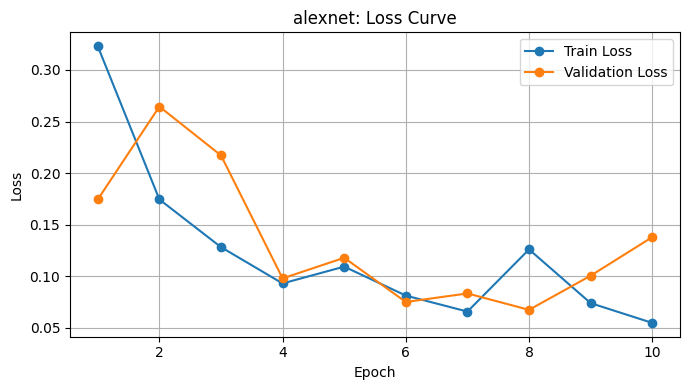

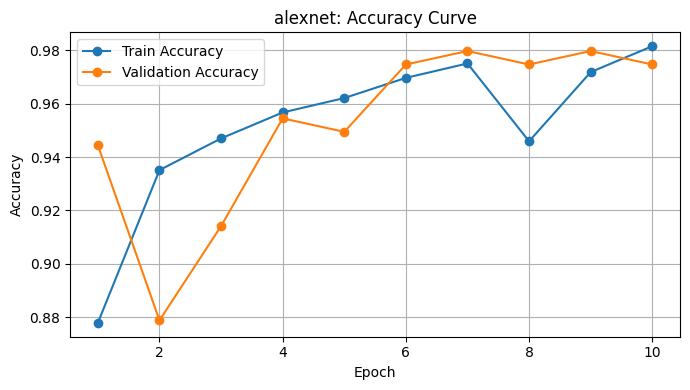

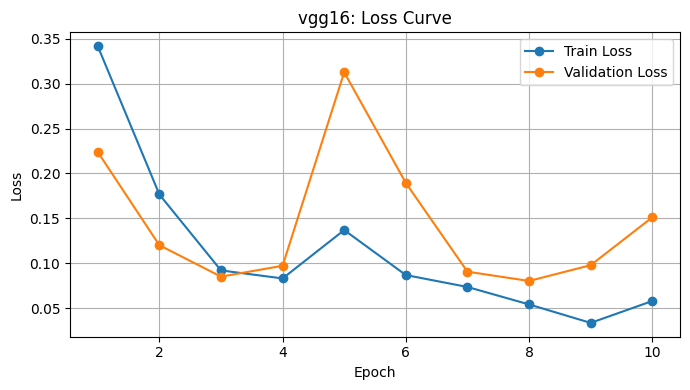

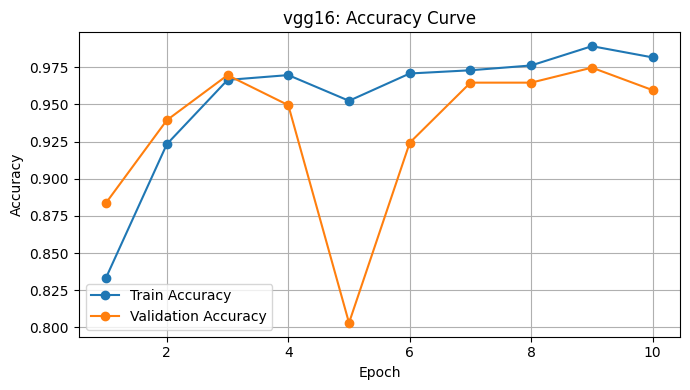

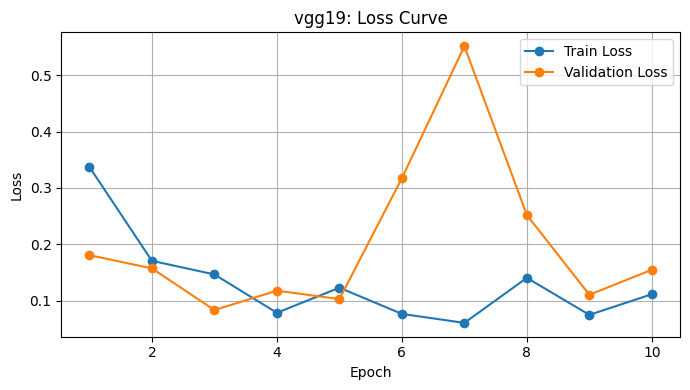

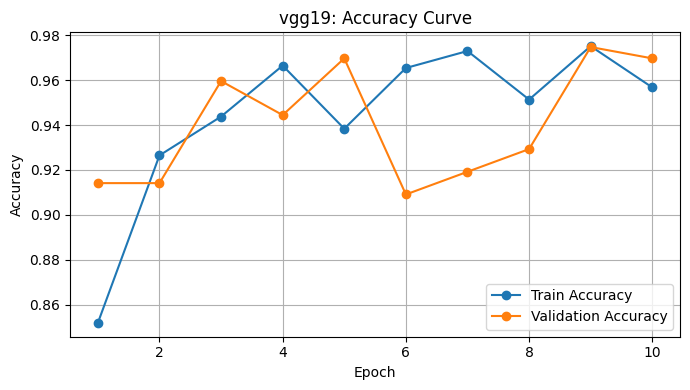

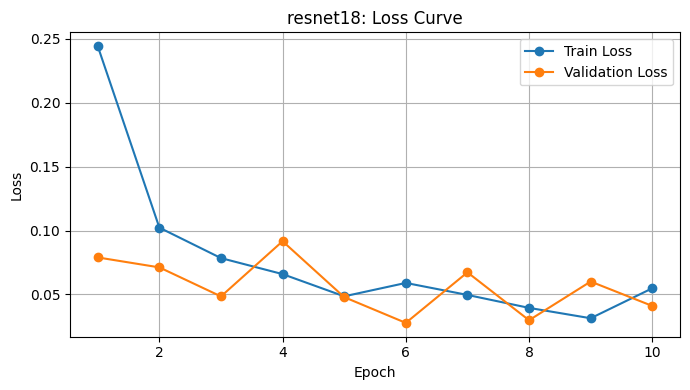

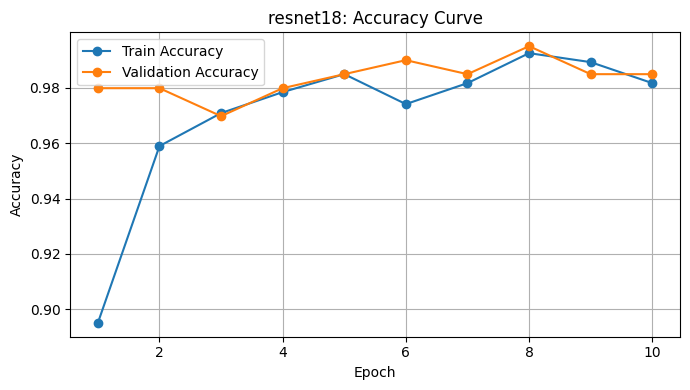

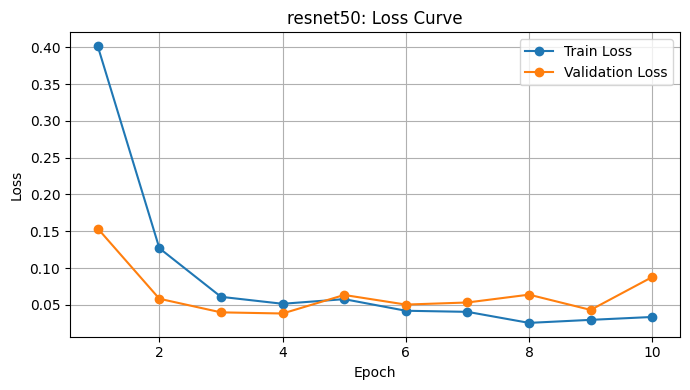

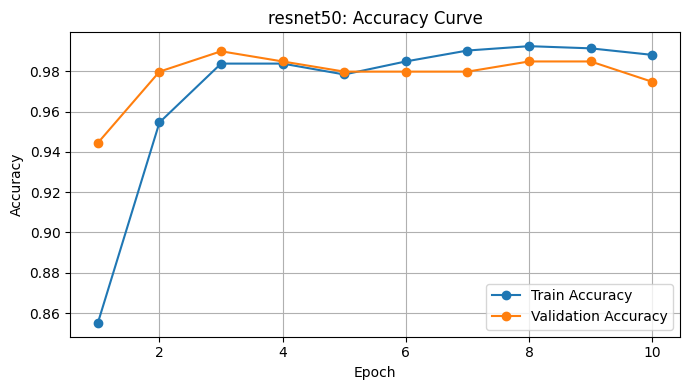

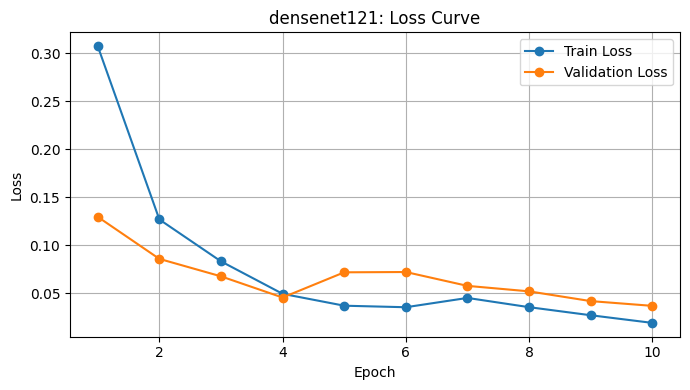

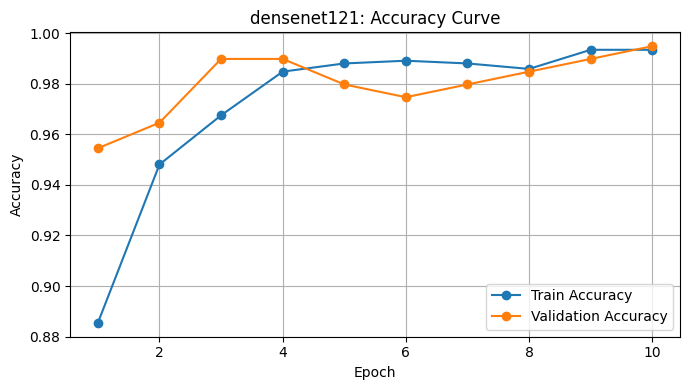

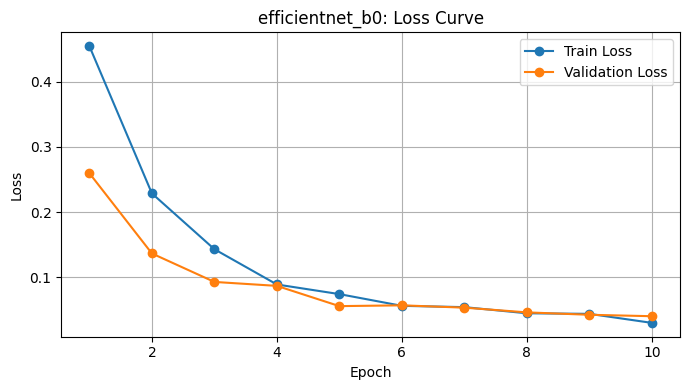

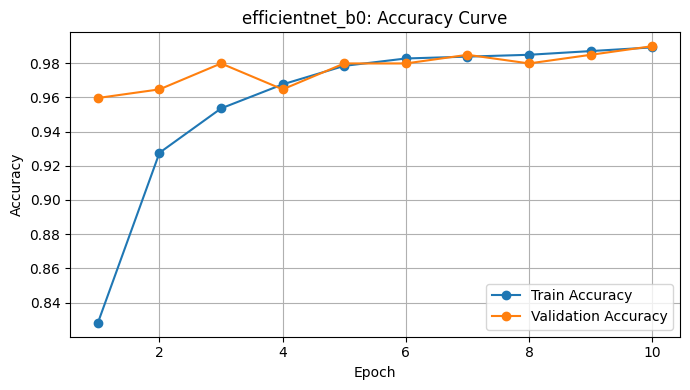

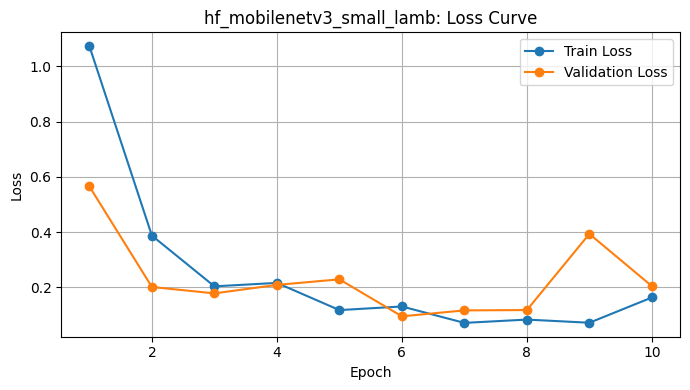

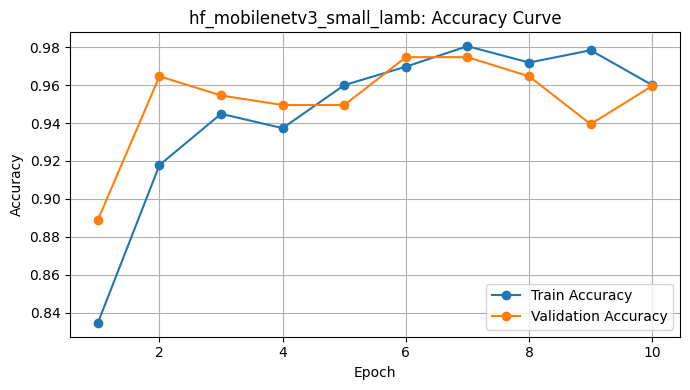

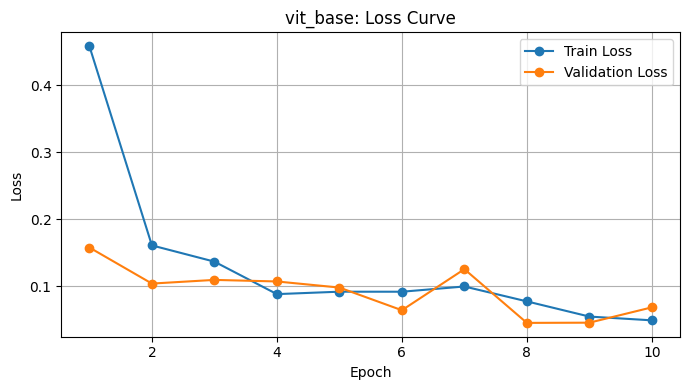

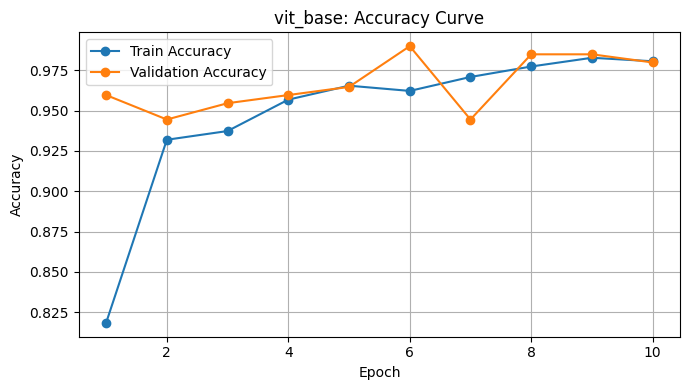

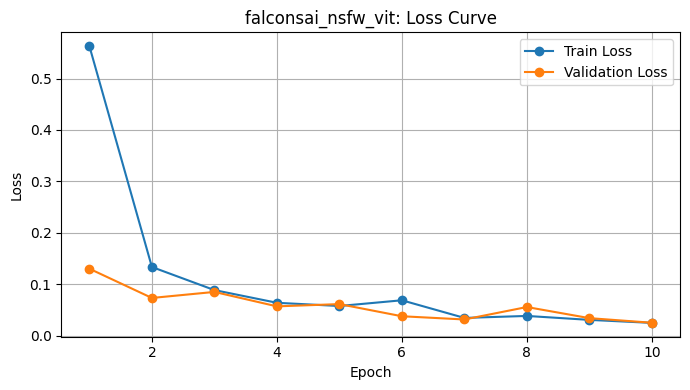

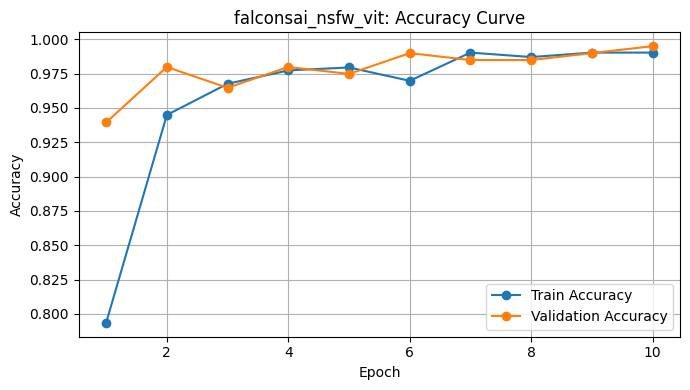

In [18]:
# Cell 11: Plot loss and accuracy

for model_name, hist in all_histories.items():

    plt.figure(figsize=(7,4))
    plt.plot(hist["epoch"], hist["train_loss"], marker="o", label="Train Loss")
    plt.plot(hist["epoch"], hist["val_loss"], marker="o", label="Validation Loss")
    plt.title(f"{model_name}: Loss Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7,4))
    plt.plot(hist["epoch"], hist["train_acc"], marker="o", label="Train Accuracy")
    plt.plot(hist["epoch"], hist["val_acc"], marker="o", label="Validation Accuracy")
    plt.title(f"{model_name}: Accuracy Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [19]:
# Cell 12: Test metrics

def compute_metrics(y_true, y_pred, y_prob):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn + 1e-9)
    specificity = tn / (tn + fp + 1e-9)

    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall/Sensitivity": sensitivity,
        "Specificity": specificity,
        "F1-score": f1_score(y_true, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "MCC": matthews_corrcoef(y_true, y_pred),
        "Cohen Kappa": cohen_kappa_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_prob),
        "PR-AUC": average_precision_score(y_true, y_prob),
        "Brier Score": brier_score_loss(y_true, y_prob),
        "TP": tp,
        "TN": tn,
        "FP": fp,
        "FN": fn
    }


results = []
pred_store = {}

for model_name, model in trained_models.items():
    test_loss, test_acc, test_f1, y_true, y_pred, y_prob = run_one_epoch(model, test_loader)

    metrics = compute_metrics(y_true, y_pred, y_prob)
    metrics["Model"] = model_name
    metrics["Test Loss"] = test_loss

    results.append(metrics)
    pred_store[model_name] = {
        "y_true": y_true,
        "y_pred": y_pred,
        "y_prob": y_prob
    }

results_df = pd.DataFrame(results)

cols = [
    "Model", "Test Loss", "Accuracy", "Precision", "Recall/Sensitivity",
    "Specificity", "F1-score", "Balanced Accuracy", "MCC",
    "Cohen Kappa", "ROC-AUC", "PR-AUC", "Brier Score",
    "TP", "TN", "FP", "FN"
]

results_df = results_df[cols]
print(results_df.round(4).to_string(index=False))
results_df.to_csv("/content/salmon_model_test_metrics.csv", index=False)

                    Model  Test Loss  Accuracy  Precision  Recall/Sensitivity  Specificity  F1-score  Balanced Accuracy    MCC  Cohen Kappa  ROC-AUC  PR-AUC  Brier Score  TP  TN  FP  FN
                  alexnet     0.1749    0.9598     0.9685              0.9685       0.9444    0.9685             0.9565 0.9129       0.9129   0.9899  0.9937       0.0367 123  68   4   4
                    vgg16     0.2209    0.9648     0.9839              0.9606       0.9722    0.9721             0.9664 0.9250       0.9245   0.9913  0.9945       0.0327 122  70   2   5
                    vgg19     0.1979    0.9698     0.9919              0.9606       0.9861    0.9760             0.9734 0.9364       0.9355   0.9950  0.9971       0.0305 122  71   1   5
                 resnet18     0.0663    0.9849     0.9921              0.9843       0.9861    0.9881             0.9852 0.9675       0.9675   0.9978  0.9988       0.0175 125  71   1   2
                 resnet50     0.1224    0.9698     0.9690             

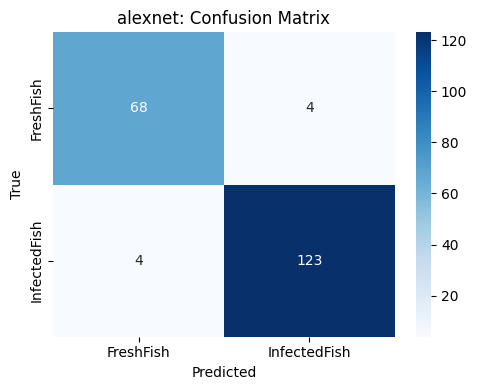

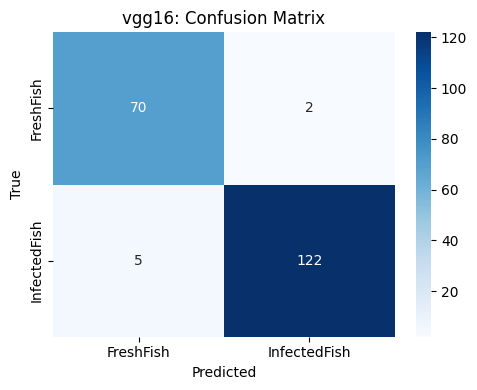

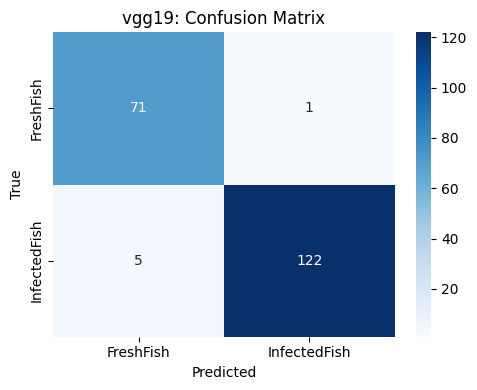

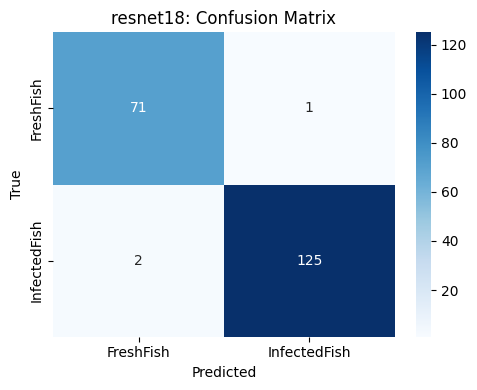

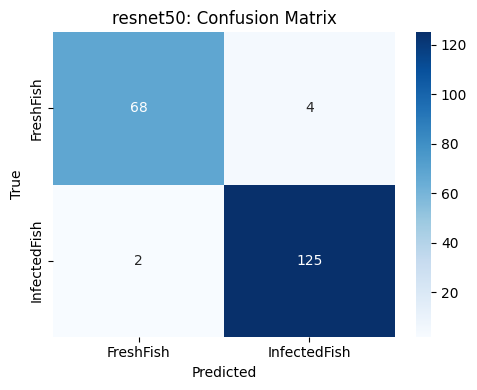

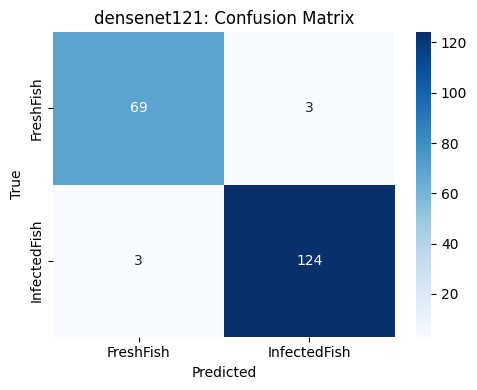

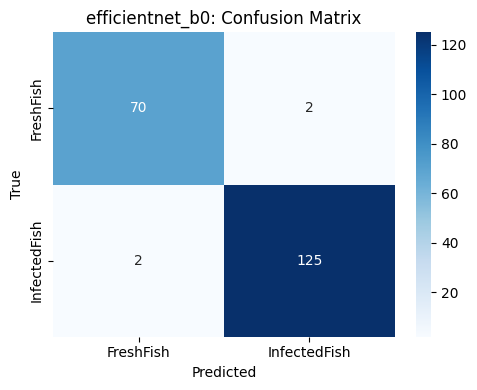

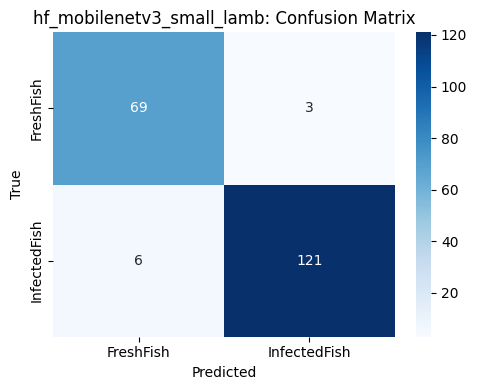

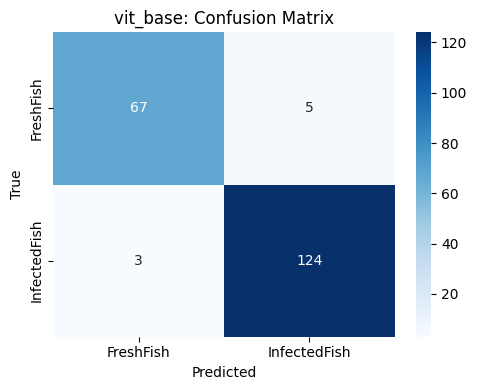

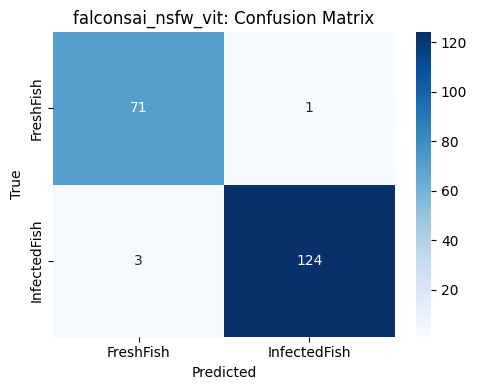

In [20]:
# Cell 13: Confusion matrices

for model_name, item in pred_store.items():
    cm = confusion_matrix(item["y_true"], item["y_pred"])

    plt.figure(figsize=(5,4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.title(f"{model_name}: Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

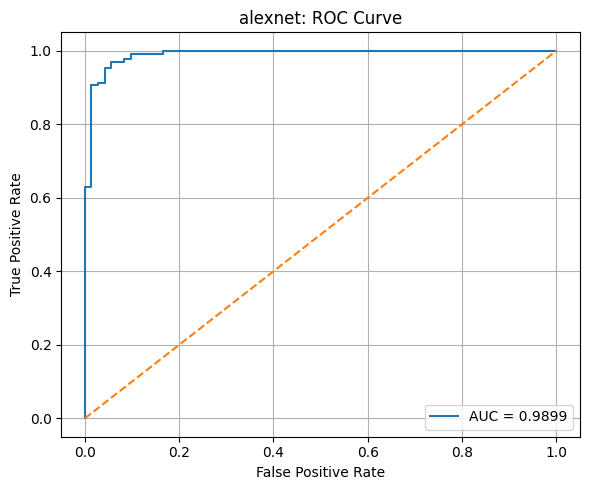

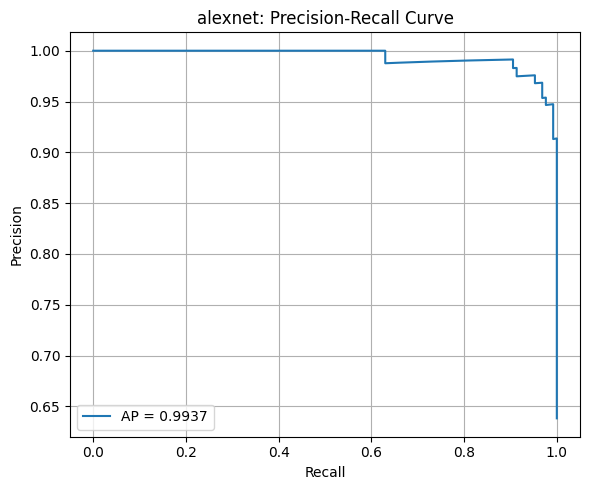

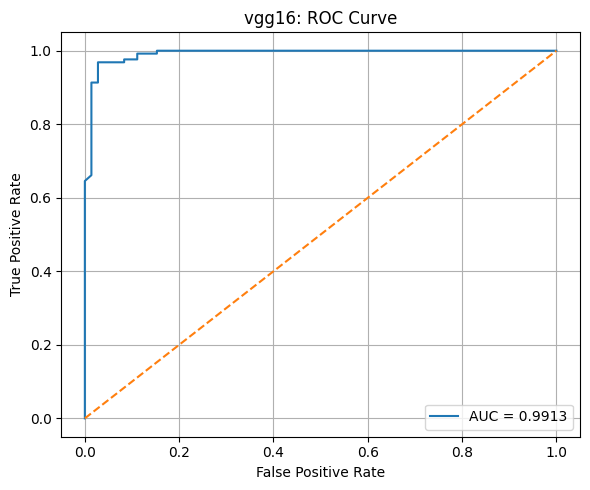

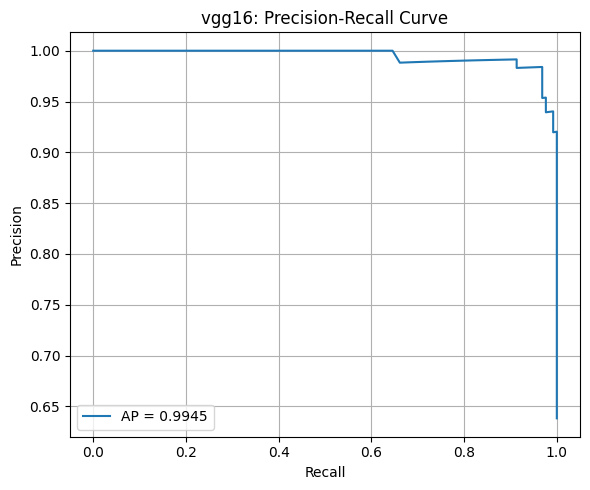

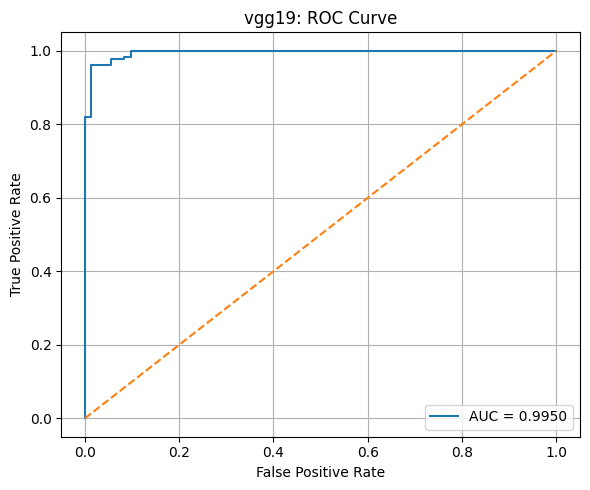

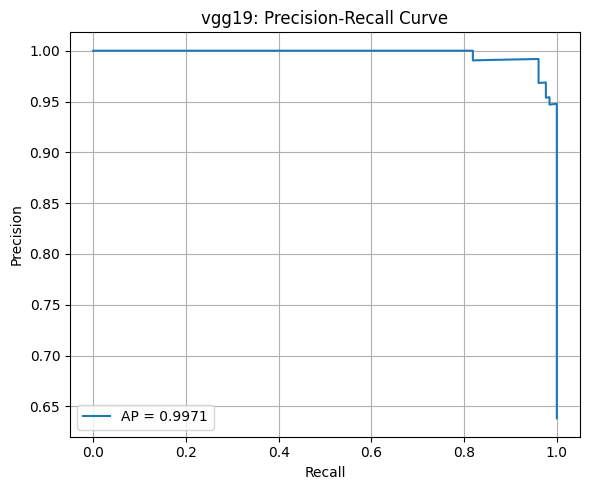

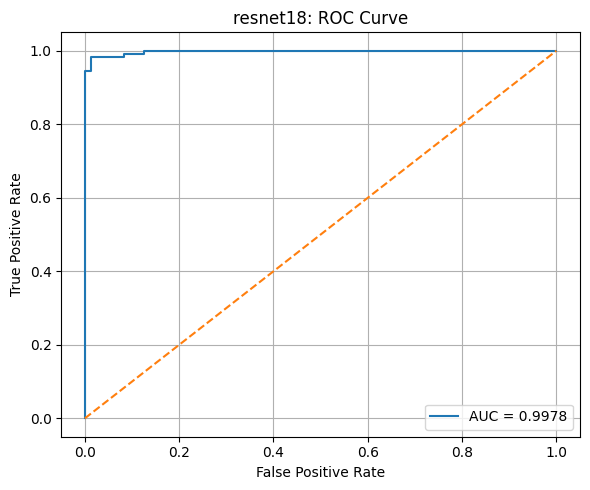

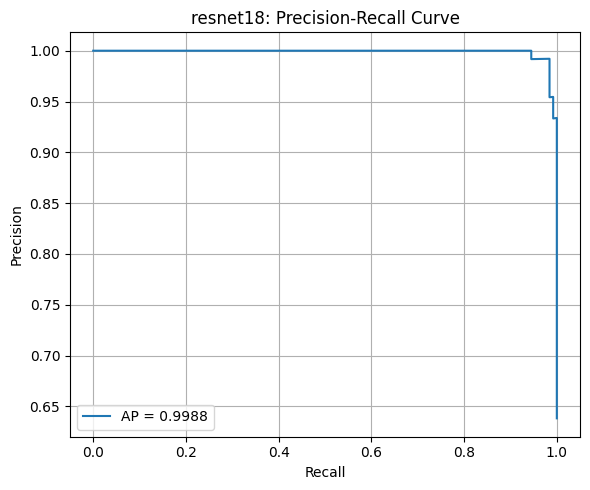

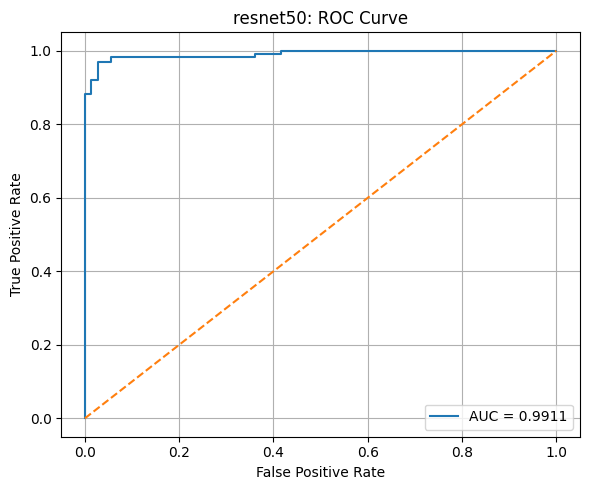

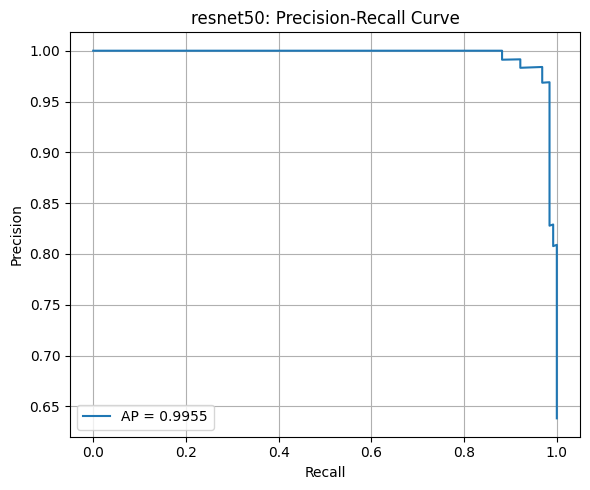

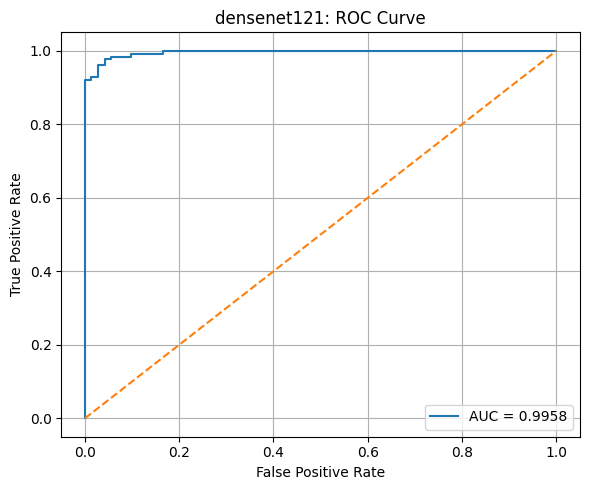

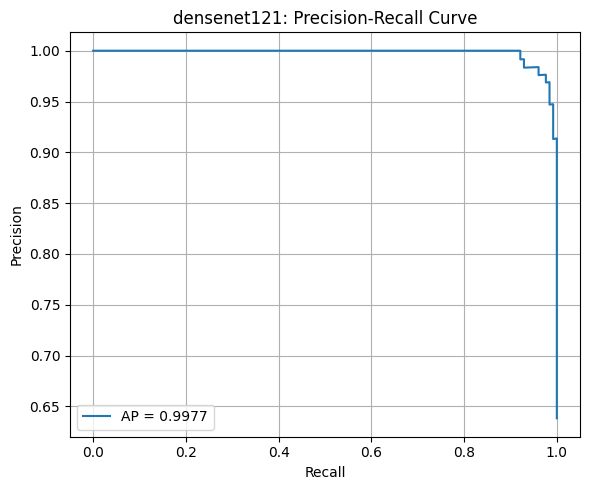

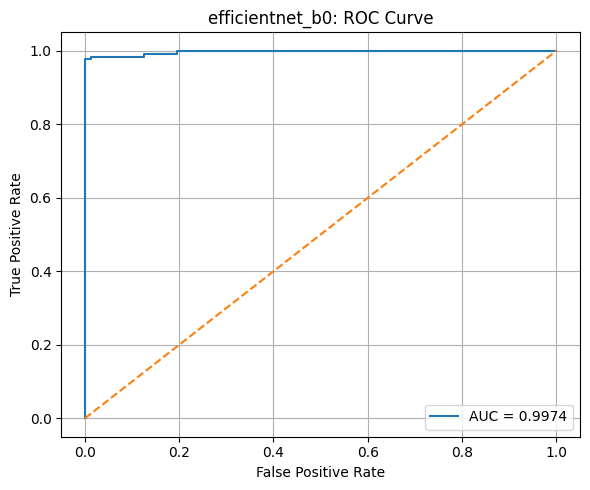

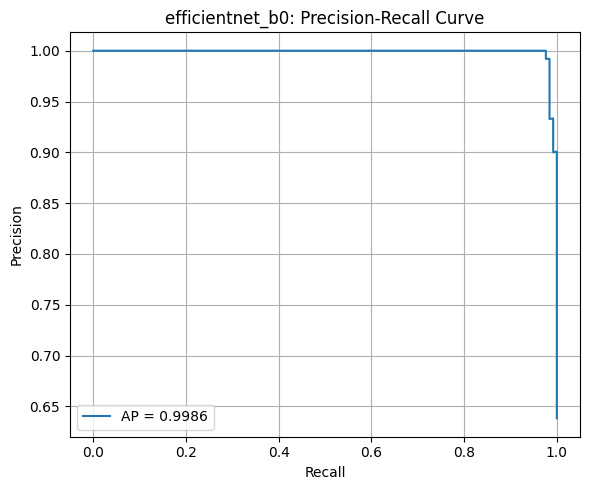

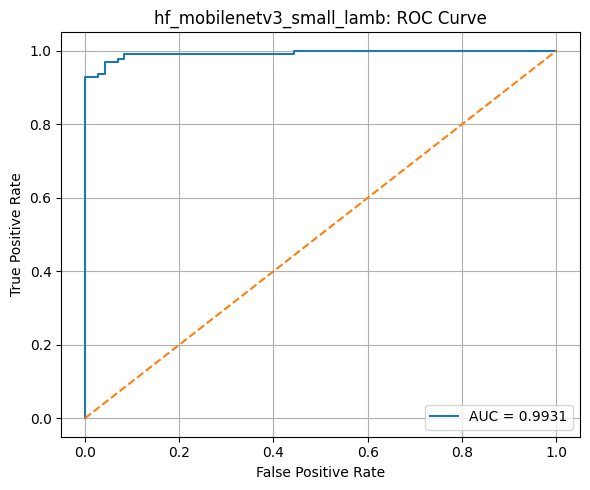

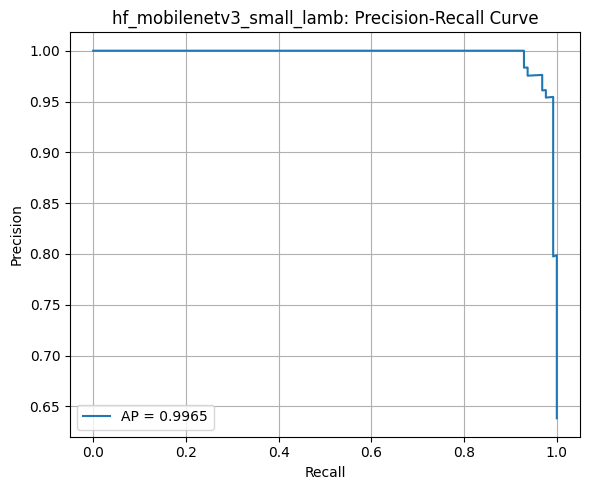

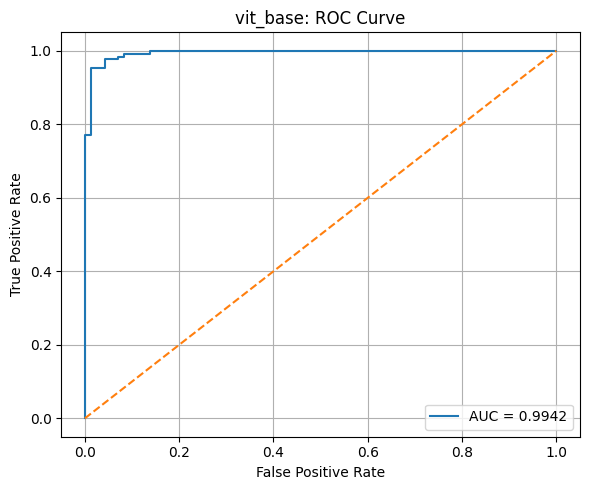

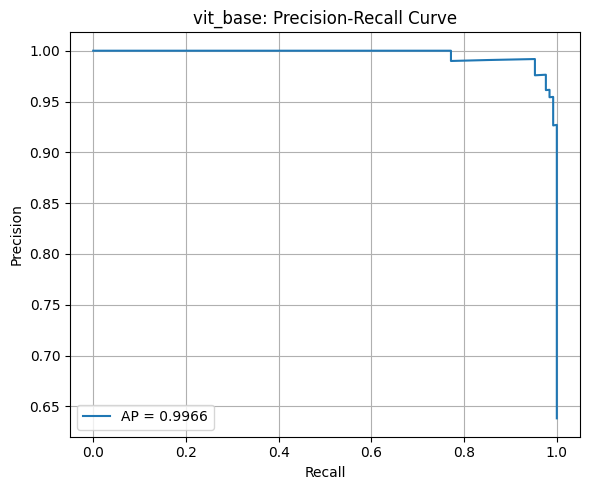

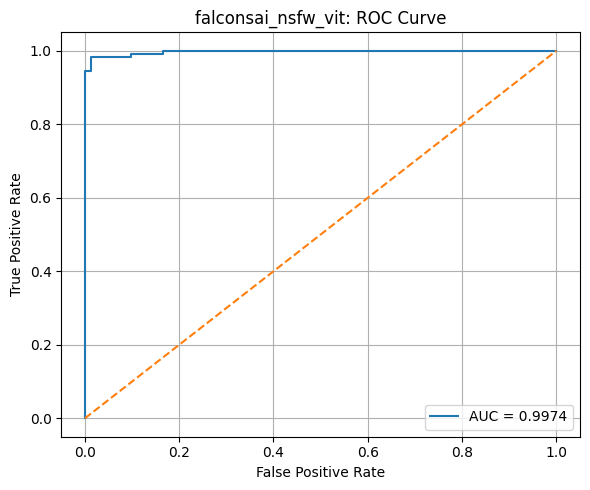

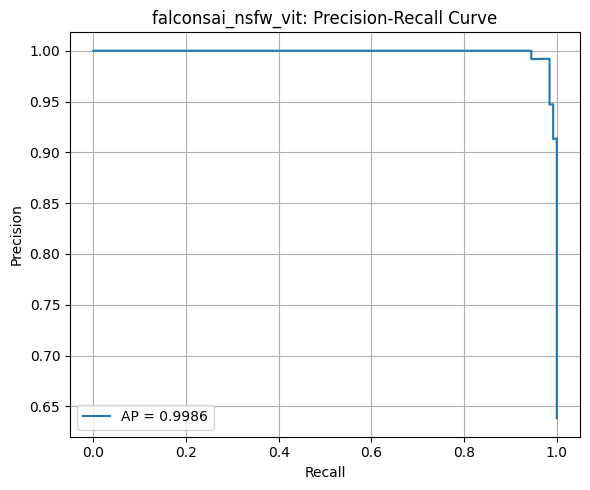

In [21]:
# Cell 14: ROC and PR curves

from sklearn.metrics import roc_curve, precision_recall_curve, auc

for model_name, item in pred_store.items():
    y_true = item["y_true"]
    y_prob = item["y_prob"]

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    precision, recall, _ = precision_recall_curve(y_true, y_prob)

    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"AUC = {auc(fpr, tpr):.4f}")
    plt.plot([0,1], [0,1], linestyle="--")
    plt.title(f"{model_name}: ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6,5))
    plt.plot(recall, precision, label=f"AP = {average_precision_score(y_true, y_prob):.4f}")
    plt.title(f"{model_name}: Precision-Recall Curve")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [22]:
# Cell 15: Copy-paste classification reports

for model_name, item in pred_store.items():
    print("\n" + "="*100)
    print(model_name)
    print("="*100)
    print(classification_report(
        item["y_true"],
        item["y_pred"],
        target_names=class_names,
        digits=4
    ))


alexnet
              precision    recall  f1-score   support

   FreshFish     0.9444    0.9444    0.9444        72
InfectedFish     0.9685    0.9685    0.9685       127

    accuracy                         0.9598       199
   macro avg     0.9565    0.9565    0.9565       199
weighted avg     0.9598    0.9598    0.9598       199


vgg16
              precision    recall  f1-score   support

   FreshFish     0.9333    0.9722    0.9524        72
InfectedFish     0.9839    0.9606    0.9721       127

    accuracy                         0.9648       199
   macro avg     0.9586    0.9664    0.9622       199
weighted avg     0.9656    0.9648    0.9650       199


vgg19
              precision    recall  f1-score   support

   FreshFish     0.9342    0.9861    0.9595        72
InfectedFish     0.9919    0.9606    0.9760       127

    accuracy                         0.9698       199
   macro avg     0.9630    0.9734    0.9677       199
weighted avg     0.9710    0.9698    0.9700       1

In [23]:
# Cell 16: Hybrid ensemble

top_models = results_df.sort_values("F1-score", ascending=False)["Model"].head(3).tolist()
print("Top models used for hybrid ensemble:", top_models)

y_true = pred_store[top_models[0]]["y_true"]
avg_prob = np.mean([pred_store[m]["y_prob"] for m in top_models], axis=0)
avg_pred = (avg_prob >= 0.5).astype(int)

ensemble_metrics = compute_metrics(y_true, avg_pred, avg_prob)
ensemble_metrics["Model"] = "Hybrid_Probability_Ensemble_Top3"
ensemble_metrics["Test Loss"] = np.nan

ensemble_df = pd.DataFrame([ensemble_metrics])[cols]
print(ensemble_df.round(4).to_string(index=False))

Top models used for hybrid ensemble: ['resnet18', 'efficientnet_b0', 'falconsai_nsfw_vit']
                           Model  Test Loss  Accuracy  Precision  Recall/Sensitivity  Specificity  F1-score  Balanced Accuracy    MCC  Cohen Kappa  ROC-AUC  PR-AUC  Brier Score  TP  TN  FP  FN
Hybrid_Probability_Ensemble_Top3        NaN    0.9849     0.9921              0.9843       0.9861    0.9881             0.9852 0.9675       0.9675   0.9976  0.9987       0.0164 125  71   1   2


In [24]:
# Cell 17: McNemar statistical test


best_two = results_df.sort_values("F1-score", ascending=False)["Model"].head(2).tolist()

m1, m2 = best_two

y_true = pred_store[m1]["y_true"]
p1 = pred_store[m1]["y_pred"]
p2 = pred_store[m2]["y_pred"]

correct1 = p1 == y_true
correct2 = p2 == y_true

table = [
    [np.sum(correct1 & correct2), np.sum(correct1 & ~correct2)],
    [np.sum(~correct1 & correct2), np.sum(~correct1 & ~correct2)]
]

result = mcnemar(table, exact=True)

print("Compared models:", m1, "vs", m2)
print("McNemar contingency table:", table)
print("Statistic:", result.statistic)
print("p-value:", result.pvalue)

Compared models: resnet18 vs efficientnet_b0
McNemar contingency table: [[np.int64(195), np.int64(1)], [np.int64(0), np.int64(3)]]
Statistic: 0.0
p-value: 1.0


In [25]:
# Cell 18: Inference speed benchmark

def benchmark_model(model, loader):
    model.eval()
    n = 0

    if DEVICE == "cuda":
        torch.cuda.synchronize()

    start = time.time()

    with torch.no_grad():
        for x, _ in loader:
            x = x.to(DEVICE)
            _ = forward_logits(model, x)
            n += x.size(0)

    if DEVICE == "cuda":
        torch.cuda.synchronize()

    elapsed = time.time() - start

    return {
        "Images": n,
        "Total Time (s)": elapsed,
        "Images/sec": n / elapsed,
        "ms/image": (elapsed / n) * 1000
    }


benchmarks = []

for model_name, model in trained_models.items():
    b = benchmark_model(model, test_loader)
    b["Model"] = model_name
    benchmarks.append(b)

bench_df = pd.DataFrame(benchmarks)
print(bench_df.round(4).to_string(index=False))
bench_df.to_csv("/content/salmon_inference_benchmark.csv", index=False)

 Images  Total Time (s)  Images/sec  ms/image                     Model
    199          1.1798    168.6750    5.9286                   alexnet
    199          1.6757    118.7587    8.4204                     vgg16
    199          2.2022     90.3646   11.0663                     vgg19
    199          1.2591    158.0514    6.3271                  resnet18
    199          1.2768    155.8542    6.4163                  resnet50
    199          1.3320    149.3998    6.6934               densenet121
    199          1.2927    153.9434    6.4959           efficientnet_b0
    199          1.2172    163.4967    6.1163 hf_mobilenetv3_small_lamb
    199          2.7185     73.2011   13.6610                  vit_base
    199          2.7390     72.6550   13.7637        falconsai_nsfw_vit


In [26]:
# Cell 19: YOLO26 classifier

from ultralytics import YOLO

yolo_model = YOLO("yolo26n-cls.pt")

yolo_results = yolo_model.train(
    data=str(WORK_DIR),
    epochs=30,
    imgsz=224,
    batch=32,
    device=0 if torch.cuda.is_available() else "cpu",
    project="/content/yolo26_salmon",
    name="yolo26n_cls_salmon",
    seed=SEED
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/salmon_ready, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, i

In [27]:
# Cell 20: YOLO26 validation

best_yolo_path = "/content/yolo26_salmon/yolo26n_cls_salmon/weights/best.pt"

best_yolo = YOLO(best_yolo_path)

yolo_metrics = best_yolo.val(
    data=str(WORK_DIR),
    split="test",
    imgsz=224,
    device=0 if torch.cuda.is_available() else "cpu"
)

print("YOLO26 Top-1 Accuracy:", yolo_metrics.top1)
print("YOLO26 Top-5 Accuracy:", yolo_metrics.top5)

Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n-cls summary (fused): 47 layers, 1,528,586 parameters, 0 gradients, 3.2 GFLOPs
train: /content/salmon_ready/train... found 925 images in 2 classes ✅ 
val: /content/salmon_ready/val... found 198 images in 2 classes ✅ 
test: /content/salmon_ready/test... found 199 images in 2 classes ✅ 
test: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2377.1±613.8 MB/s, size: 262.6 KB)
test: Scanning /content/salmon_ready/test... 199 images, 0 corrupt: 100% ━━━━━━━━━━━━ 199/199 2.0Kit/s 0.1s
test: New cache created: /content/salmon_ready/test.cache
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 13/13 8.3it/s 1.6s
                   all       0.96          1
Speed: 0.7ms preprocess, 2.5ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /content/runs/classify/val
YOLO26 Top-1 Accuracy: 0.9597989916801453
YOLO26 Top-5 Accuracy: 1.0


In [28]:
# Cell 21: Export all publication tables

final_results_df = pd.concat([results_df, ensemble_df], ignore_index=True)

with pd.ExcelWriter("/content/salmon_publication_results_full.xlsx") as writer:
    dist_df.to_excel(writer, sheet_name="Dataset_Distribution", index=False)
    final_results_df.to_excel(writer, sheet_name="Model_Test_Metrics", index=False)
    bench_df.to_excel(writer, sheet_name="Inference_Benchmark", index=False)

print("Saved: /content/salmon_publication_results_full.xlsx")
print(final_results_df.round(4).to_string(index=False))

Saved: /content/salmon_publication_results_full.xlsx
                           Model  Test Loss  Accuracy  Precision  Recall/Sensitivity  Specificity  F1-score  Balanced Accuracy    MCC  Cohen Kappa  ROC-AUC  PR-AUC  Brier Score  TP  TN  FP  FN
                         alexnet     0.1749    0.9598     0.9685              0.9685       0.9444    0.9685             0.9565 0.9129       0.9129   0.9899  0.9937       0.0367 123  68   4   4
                           vgg16     0.2209    0.9648     0.9839              0.9606       0.9722    0.9721             0.9664 0.9250       0.9245   0.9913  0.9945       0.0327 122  70   2   5
                           vgg19     0.1979    0.9698     0.9919              0.9606       0.9861    0.9760             0.9734 0.9364       0.9355   0.9950  0.9971       0.0305 122  71   1   5
                        resnet18     0.0663    0.9849     0.9921              0.9843       0.9861    0.9881             0.9852 0.9675       0.9675   0.9978  0.9988       0.017